In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import scipy.io as sio
from scipy.linalg import expm

In [2]:
n = 2
cov1 = np.array(
    [
        [0.5 ** 2, 0.1],
        [0.1, 0.4 ** 2],
    ]
)
cov2 = np.array(
    [
        [0.5 ** 2, -0.1],
        [-0.1, 0.4 ** 2],
    ]
)
mu1 = np.array([-0.7, 0]).reshape([1, 2])
mu2 = np.array([0.7, 0]).reshape([1, 2])

alpha = 1
eps = 1
T = 1

In [3]:
y01 = np.random.multivariate_normal(mean=mu1.flatten(), cov=cov1, size=500000)
y02 = np.random.multivariate_normal(mean=mu2.flatten(), cov=cov2, size=500000)
y0 = np.concatenate([y01, y02], axis=0)

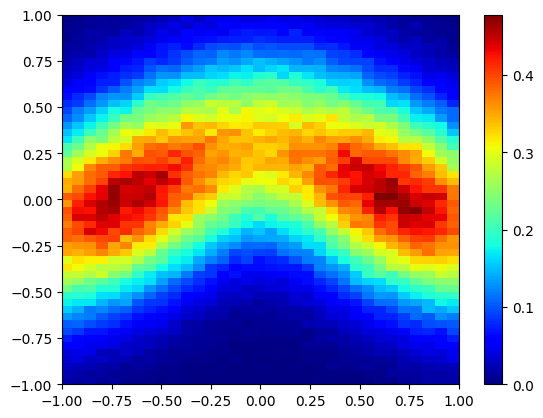

In [4]:
plt.hist2d(y0[:, 0], y0[:, 1], bins=(100, 100), density=True, cmap=colormaps["jet"])
plt.xlim([-1., 1.])
plt.ylim([-1., 1.])
plt.colorbar()
plt.show()

In [5]:
Nt = 101
t = np.linspace(0, T, Nt)
ys = [y0]
dt = t[1] - t[0]
for i in range(int(T/dt)):
    ys += [ys[-1] + np.sqrt(dt * eps) * np.random.normal(size=y0.shape)]
ys = np.stack(ys)
ys = np.transpose(ys, [1, 0, 2])

In [8]:
sio.savemat(
    "./train.mat",
    {
        "t": t,
        "ys": ys,
        "eps": eps,
        "alpha": alpha,
        "T": T
    }
)